# Star Schema and Analytical Queries for Financial Transactions

## Homework #3 - Big Data Analytics



In [1]:
# ============================================================
# 1. Imports and settings
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Wider output when inspecting the dataframes.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Chart defaults.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

# Thousands separator for axis labels (e.g. 1,250,000), used on the charts later.
def thousands_formatter(x, pos):
    return f"{x:,.0f}"

# CSV folder. Change this if you keep the files in a subfolder (e.g. Path("data")).
DATA_DIR = Path(".")

In [2]:
# ============================================================
# 2. Load the raw data
# ============================================================

# The account and symbols files are ";"-separated with a UTF-8 BOM ("utf-8-sig");
# country.csv is a standard comma-separated ISO 3166 table.
account_raw = pd.read_csv(DATA_DIR / "account-statement-1-1-2024-12-31-2024.csv",
                          sep=";", encoding="utf-8-sig")
symbols_raw = pd.read_csv(DATA_DIR / "symbols.csv",
                          sep=";", encoding="utf-8-sig")
country_raw = pd.read_csv(DATA_DIR / "country.csv")

print("account_raw:", account_raw.shape)
print("symbols_raw:", symbols_raw.shape)
print("country_raw:", country_raw.shape)

account_raw: (2745, 6)
symbols_raw: (3194, 5)
country_raw: (249, 11)


In [3]:
# ============================================================
# 3. Data quality inspection
# ============================================================

# Reused on every table: dtype and missing values per column.
def quality_summary(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(1),
    })

print("account_raw shape:", account_raw.shape)
quality_summary(account_raw)

account_raw shape: (2745, 6)


,dtype,missing,missing_pct
IDTransaction,float64,464,16.9
Date,str,464,16.9
TransactionType,str,464,16.9
Symbol,str,464,16.9
Unit,float64,464,16.9
Unnamed: 5,float64,2745,100.0


In [4]:
# The phantom last column is entirely empty (caused by the trailing ";").
print("'Unnamed: 5' fully empty:", account_raw["Unnamed: 5"].isna().all())

# Some rows are completely blank: all five meaningful columns are NaN.
meaningful_cols = ["IDTransaction", "Date", "TransactionType", "Symbol", "Unit"]
n_empty = account_raw[meaningful_cols].isna().all(axis=1).sum()
print("Fully empty rows:", n_empty, "-> valid rows:", len(account_raw) - n_empty)

# Transaction types present. DIVIDENT (a typo for DIVIDEND) is a dividend event,
# not a trade, so it will not show up in the BUY/SELL questions.
account_raw["TransactionType"].value_counts(dropna=False)

'Unnamed: 5' fully empty: True
Fully empty rows: 464 -> valid rows: 2281


TransactionType
SELL        1089
BUY         1082
NaN          464
DIVIDENT     110
Name: count, dtype: int64

In [5]:
# Reference tables: we check shape and the columns we will actually use.
print("symbols_raw shape:", symbols_raw.shape)
print("country_raw shape:", country_raw.shape)

print("\nMissing in symbols (used cols):")
print(symbols_raw[["symbol", "company_name", "sector", "industry", "country"]].isna().sum())

print("\nMissing in country (used cols):")
print(country_raw[["name", "region", "sub-region"]].isna().sum())

symbols_raw shape: (3194, 5)
country_raw shape: (249, 11)

Missing in symbols (used cols):
symbol          0
company_name    0
sector          0
industry        0
country         0
dtype: int64

Missing in country (used cols):
name          0
region        2
sub-region    2
dtype: int64


In [6]:
# ============================================================
# 4. Clean the account statement
# ============================================================

# Work on a copy so the raw dataframe stays available for reference.
account = account_raw.drop(columns=["Unnamed: 5"]).copy()

# Drop the fully empty rows (the 464 blank lines), then reset the index.
account = account.dropna(how="all").reset_index(drop=True)

# Parse the timestamp with the file's explicit format (day first).
account["Date"] = pd.to_datetime(account["Date"], format="%d/%m/%Y %H:%M:%S")

# IDTransaction and Unit came in as floats because of the dropped NaNs;
# turn them back into plain integers (IDTransaction is kept only as a label later).
account["IDTransaction"] = account["IDTransaction"].astype(int)
account["Unit"] = account["Unit"].astype(int)

print("Cleaned account:", account.shape)
account.head()

Cleaned account: (2281, 5)


,IDTransaction,Date,TransactionType,Symbol,Unit
0,2769834124,2024-01-11 10:44:03,BUY,BAP,1605
1,2767324642,2024-01-24 08:07:24,SELL,BAP,1605
2,2815473914,2024-01-10 11:00:08,SELL,BAP,914
3,2622244212,2024-01-16 08:14:21,BUY,ACGL,646
4,2629871124,2024-01-16 14:34:12,SELL,ALVO,646


In [7]:
# ============================================================
# 5. Integrity checks and modeling decisions
# ============================================================

# 5.1 - Every transaction symbol must exist in symbols.csv.
known_symbols = set(symbols_raw["symbol"])
unmapped_mask = ~account["Symbol"].isin(known_symbols)
print("Unknown-symbol transactions:", unmapped_mask.sum(),
      f"({unmapped_mask.mean() * 100:.1f}%)",
      "from", account.loc[unmapped_mask, "Symbol"].nunique(), "distinct symbols")

# They cannot be mapped to sector/industry/country, so we exclude them and
# keep only the mapped transactions for the dimensional analysis.
account_mapped = account[~unmapped_mask].reset_index(drop=True)
print("Mapped transactions kept:", len(account_mapped))

# 5.2 - Align company countries to the ISO 3166 names in country.csv.
# Only two names differ; after this replacement every country name matches.
symbols = symbols_raw.copy()
symbols["country"] = symbols["country"].replace({
    "Taiwan": "Taiwan, Province of China",
    "Turkey": "Türkiye",
})
unmatched = set(symbols["country"]) - set(country_raw["name"])
print("Company countries still unmatched after fix:", len(unmatched))

# 5.3 - IDTransaction is not unique (the same id is reused on different rows),
# so it cannot be the fact primary key. The fact will use a surrogate key and
# IDTransaction is kept only as a descriptive (degenerate) attribute.
print("IDTransaction: distinct =", account["IDTransaction"].nunique(),
      "of", len(account), "rows")

# 5.4 - region/sub-region must be available for the traded countries.
geo_lookup = country_raw.set_index("name")[["region", "sub-region"]]
traded_countries = (account_mapped
                    .merge(symbols[["symbol", "country"]],
                           left_on="Symbol", right_on="symbol", how="left")
                    ["country"].dropna().unique())
missing_geo = [c for c in traded_countries
               if c in geo_lookup.index and geo_lookup.loc[c].isna().any()]
print("Traded countries missing region/sub-region:", missing_geo)

Unknown-symbol transactions: 212 (9.3%) from 18 distinct symbols
Mapped transactions kept: 2069
Company countries still unmatched after fix: 0
IDTransaction: distinct = 1136 of 2281 rows
Traded countries missing region/sub-region: ['Taiwan, Province of China']


In [8]:
# ============================================================
# 6. Dim_Time
# ============================================================

# Grain: one row per calendar date that appears in the transactions.
# Hierarchy: Day -> Month -> Quarter -> Year.
unique_dates = pd.Series(account_mapped["Date"].dt.normalize().unique()).sort_values()
dim_time = pd.DataFrame({"date": unique_dates.reset_index(drop=True)})

dim_time["day"] = dim_time["date"].dt.day
dim_time["month"] = dim_time["date"].dt.month
dim_time["quarter"] = dim_time["date"].dt.quarter
dim_time["year"] = dim_time["date"].dt.year

# Surrogate primary key.
dim_time.insert(0, "time_key", range(1, len(dim_time) + 1))

print("Dim_Time:", dim_time.shape)
dim_time.head()

Dim_Time: (228, 6)


,time_key,date,day,month,quarter,year
0,1,2024-01-02,2,1,1,2024
1,2,2024-01-03,3,1,1,2024
2,3,2024-01-04,4,1,1,2024
3,4,2024-01-05,5,1,1,2024
4,5,2024-01-08,8,1,1,2024


In [9]:
# ============================================================
# 7. Dim_Geography
# ============================================================

# Grain: one row per country actually traded.
# country / region / sub_region live ONLY here (not in Dim_Symbol) to avoid duplication.
# We take the country of every traded company, then attach the ISO 3166 region info.
traded_symbols = account_mapped["Symbol"].unique()
traded_countries = sorted(symbols.loc[symbols["symbol"].isin(traded_symbols), "country"].unique())

geo = country_raw[["name", "region", "sub-region"]].rename(
    columns={"name": "country", "sub-region": "sub_region"})

dim_geography = pd.DataFrame({"country": traded_countries}).merge(geo, on="country", how="left")
dim_geography.insert(0, "geography_key", range(1, len(dim_geography) + 1))

print("Dim_Geography:", dim_geography.shape)
dim_geography

Dim_Geography: (21, 4)


,geography_key,country,region,sub_region
0,1,Bermuda,Americas,Northern America
1,2,Brazil,Americas,Latin America and the Caribbean
2,3,Canada,Americas,Northern America
3,4,Cayman Islands,Americas,Latin America and the Caribbean
4,5,China,Asia,Eastern Asia
5,6,Germany,Europe,Western Europe
6,7,Greece,Europe,Southern Europe
7,8,India,Asia,Southern Asia
8,9,Ireland,Europe,Northern Europe
9,10,Israel,Asia,Western Asia


In [10]:
# ============================================================
# 8. Dim_Symbol
# ============================================================

# Grain: one row per traded symbol. Hierarchy: Sector -> Industry -> Company.
# Country is intentionally NOT here (it lives in Dim_Geography only).
dim_symbol = (symbols[symbols["symbol"].isin(traded_symbols)]
              [["symbol", "company_name", "sector", "industry"]]
              .drop_duplicates(subset="symbol")
              .sort_values("symbol")
              .reset_index(drop=True))

dim_symbol.insert(0, "symbol_key", range(1, len(dim_symbol) + 1))

print("Dim_Symbol:", dim_symbol.shape)
dim_symbol.head()

Dim_Symbol: (111, 5)


,symbol_key,symbol,company_name,sector,industry
0,1,AAPL,Apple Inc.,Technology,Consumer Electronics
1,2,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified
2,3,ACN,Accenture plc,Technology,Information Technology Services
3,4,ACTG,Acacia Research Corporation,Industrials,Business Equipment & Supplies
4,5,AIR,AAR Corp.,Industrials,Aerospace & Defense


In [11]:
# ============================================================
# 9. Dim_TransactionType
# ============================================================

# Small dimension: one row per transaction type (BUY, SELL, DIVIDENT).
dim_transaction_type = pd.DataFrame(
    {"transaction_type": sorted(account_mapped["TransactionType"].unique())})
dim_transaction_type.insert(0, "transaction_type_key",
                            range(1, len(dim_transaction_type) + 1))

print("Dim_TransactionType:", dim_transaction_type.shape)
dim_transaction_type

Dim_TransactionType: (3, 2)


,transaction_type_key,transaction_type
0,1,BUY
1,2,DIVIDENT
2,3,SELL


In [12]:
# ============================================================
# 10. Fact_Transactions
# ============================================================

# Grain: one row per mapped transaction, identified by a surrogate key.
# Foreign keys are resolved with simple lookups (.map). The geography key
# takes two hops: symbol -> company country -> geography_key.
time_map = dim_time.set_index("date")["time_key"]
symbol_map = dim_symbol.set_index("symbol")["symbol_key"]
type_map = dim_transaction_type.set_index("transaction_type")["transaction_type_key"]
symbol_country = symbols.set_index("symbol")["country"]
geo_map = dim_geography.set_index("country")["geography_key"]

fact_transactions = pd.DataFrame({
    # IDTransaction is kept only as a degenerate (descriptive) attribute.
    "IDTransaction": account_mapped["IDTransaction"].values,
    "time_key": account_mapped["Date"].dt.normalize().map(time_map).values,
    "geography_key": account_mapped["Symbol"].map(symbol_country).map(geo_map).values,
    "symbol_key": account_mapped["Symbol"].map(symbol_map).values,
    "transaction_type_key": account_mapped["TransactionType"].map(type_map).values,
    # Measures: traded units, and a constant 1 to count transactions.
    "units": account_mapped["Unit"].values,
    "transaction_count": 1,
})
fact_transactions.insert(0, "transaction_key", range(1, len(fact_transactions) + 1))

print("Fact_Transactions:", fact_transactions.shape)
print("FK nulls:", fact_transactions[["time_key", "geography_key",
      "symbol_key", "transaction_type_key"]].isna().sum().to_dict())
fact_transactions.head()

Fact_Transactions: (2069, 8)
FK nulls: {'time_key': 0, 'geography_key': 0, 'symbol_key': 0, 'transaction_type_key': 0}


,transaction_key,IDTransaction,time_key,geography_key,symbol_key,transaction_type_key,units,transaction_count
0,1,2769834124,8,16,21,1,1605,1
1,2,2767324642,17,16,21,3,1605,1
2,3,2815473914,7,16,21,3,914,1
3,4,2622244212,11,1,2,1,646,1
4,5,2629871124,11,11,8,3,646,1


## Part 2 - Analytical questions

We answer the five questions by querying the star schema. First we join the fact table to its four dimensions into a single analytical view; then each question simply filters and aggregates that view on the dimension attributes.

In [13]:
# ============================================================
# 11. Analytical view (fact joined to its dimensions)
# ============================================================

# Join the fact to its four dimensions once. Every question below queries
# this denormalized view by filtering and aggregating on dimension attributes.
star = (fact_transactions
        .merge(dim_time, on="time_key")
        .merge(dim_geography, on="geography_key")
        .merge(dim_symbol, on="symbol_key")
        .merge(dim_transaction_type, on="transaction_type_key"))

print("star:", star.shape)

star: (2069, 21)


# Business Question 1

## Top 5 sectors by SELL transactions in the US (2024)

> What are the top 5 sectors by number of SELL transactions in US during 2024?

sector
Technology                158
Communication Services     58
Financial Services         55
Healthcare                 50
Consumer Cyclical          48
Name: transaction_count, dtype: int64


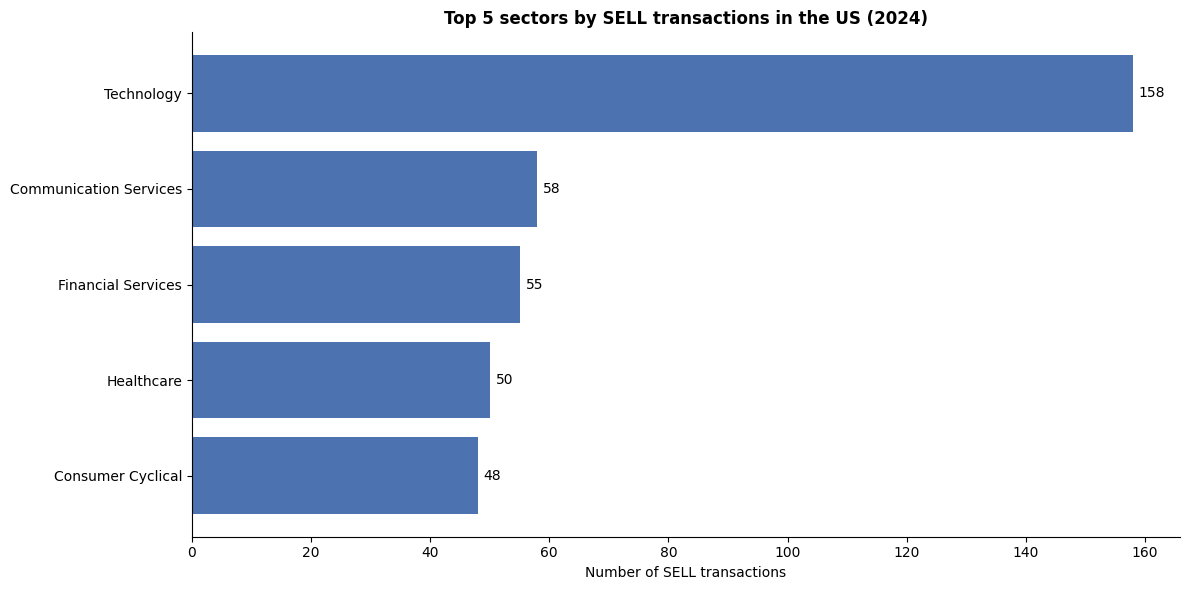

In [14]:
# Q1 - top 5 sectors by SELL transactions in the US during 2024.
q1_mask = ((star["transaction_type"] == "SELL") &
           (star["country"] == "United States of America") &
           (star["year"] == 2024))

q1 = (star[q1_mask]
      .groupby("sector")["transaction_count"].sum()
      .sort_values(ascending=False)
      .head(5))
print(q1)

# Horizontal bar chart, largest sector on top.
sectors = q1.sort_values()
fig, ax = plt.subplots()
ax.barh(sectors.index, sectors.values, color="#4C72B0")
ax.set_title("Top 5 sectors by SELL transactions in the US (2024)")
ax.set_xlabel("Number of SELL transactions")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for i, v in enumerate(sectors.values):
    ax.text(v + 1, i, str(int(v)), va="center")
plt.tight_layout()
plt.show()

### Interpretation

Technology clearly dominates US SELL activity with 158 transactions - more than the next two sectors combined. Communication Services (58), Financial Services (55), Healthcare (50) and Consumer Cyclical (48) follow at a similar, much lower level. So selling in the US portfolio is heavily concentrated in tech.

# Business Question 3

## Ranking of 2024 quarters by total BUY+SELL transactions

> Rank all quarters of 2024 by total number of transactions (BUY + SELL).

quarter
1    968
2    522
3    242
4    241
Name: transaction_count, dtype: int64


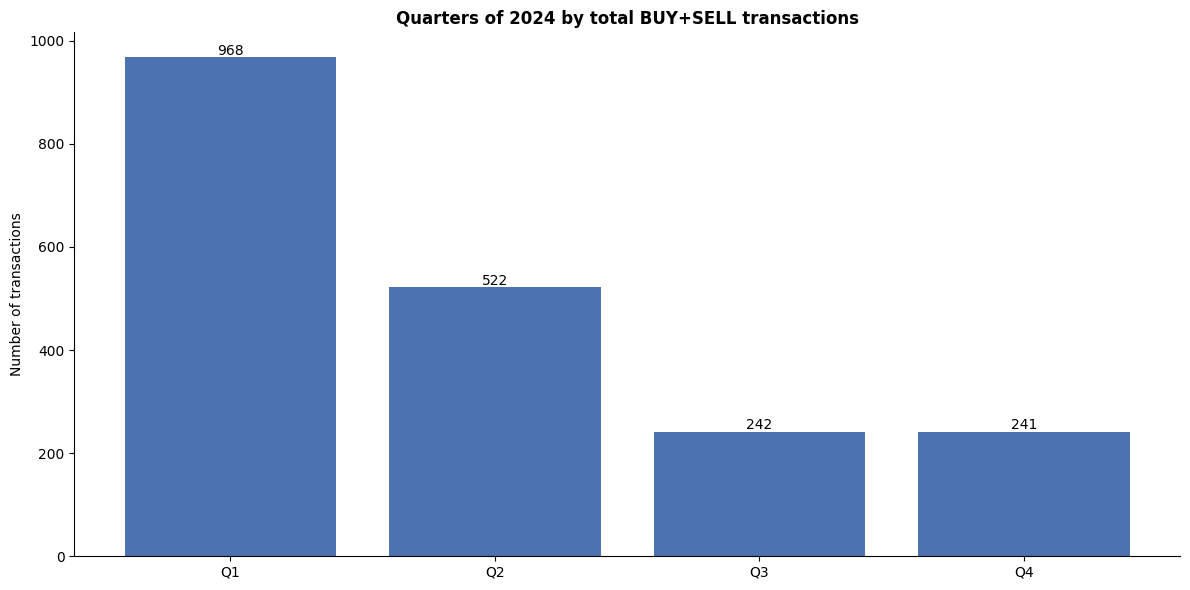

In [15]:
# Q3 - rank all quarters of 2024 by total BUY+SELL transactions (DIVIDENT excluded).
q3_mask = star["transaction_type"].isin(["BUY", "SELL"]) & (star["year"] == 2024)

q3 = (star[q3_mask]
      .groupby("quarter")["transaction_count"].sum()
      .sort_values(ascending=False))
print(q3)

# Bar chart in calendar order (which here is also the ranking).
quarters = q3.sort_index()
labels = [f"Q{q}" for q in quarters.index]
fig, ax = plt.subplots()
ax.bar(labels, quarters.values, color="#4C72B0")
ax.set_title("Quarters of 2024 by total BUY+SELL transactions")
ax.set_ylabel("Number of transactions")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for i, v in enumerate(quarters.values):
    ax.text(i, v + 5, str(int(v)), ha="center")
plt.tight_layout()
plt.show()

### Interpretation

Activity falls steeply through the year. Q1 alone has 968 BUY+SELL transactions, almost half of the 1,973 total, then it roughly halves in Q2 (522) and drops again in the second half, where Q3 (242) and Q4 (241) are basically tied. The full ranking is Q1 > Q2 > Q3 > Q4.

# Business Question 4

## Top 10 countries by SELL transactions (2024)

> What are the top 10 countries by number of SELL transactions in 2024?

country
United States of America                                389
United Kingdom of Great Britain and Northern Ireland    130
China                                                   112
Brazil                                                   69
Taiwan, Province of China                                50
Netherlands, Kingdom of the                              46
Switzerland                                              37
Ireland                                                  31
Luxembourg                                               27
Canada                                                   22
Name: transaction_count, dtype: int64


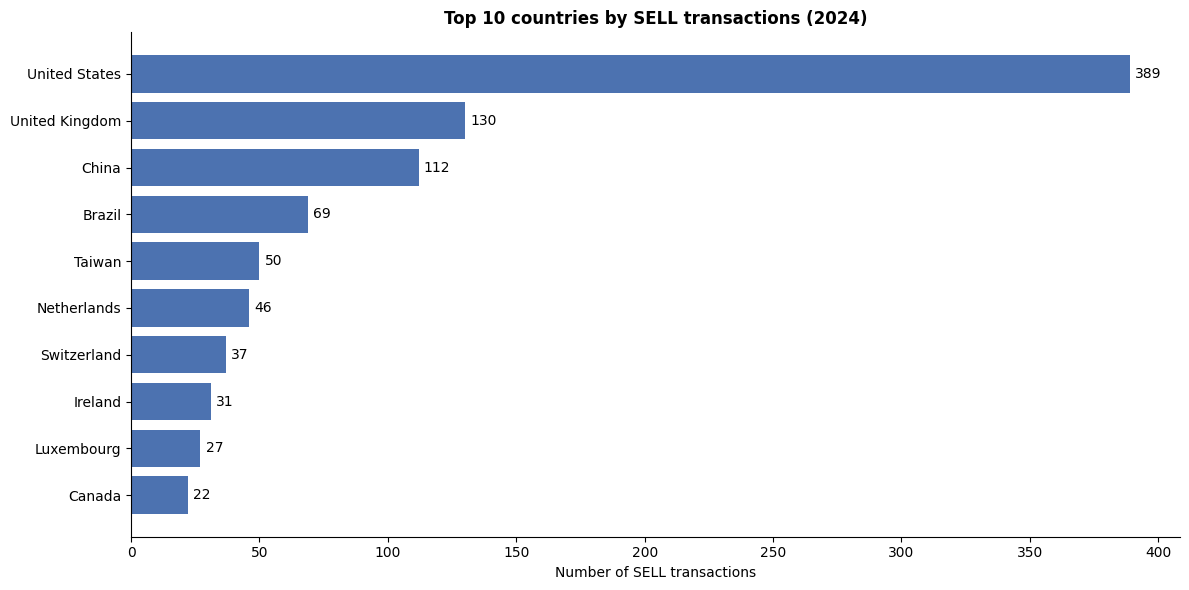

In [16]:
# Q4 - top 10 countries by SELL transactions in 2024.
q4_mask = (star["transaction_type"] == "SELL") & (star["year"] == 2024)

q4 = (star[q4_mask]
      .groupby("country")["transaction_count"].sum()
      .sort_values(ascending=False)
      .head(10))
print(q4)

# Shorter labels for the chart only (the full ISO names stay in the data above).
short_names = {
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Netherlands, Kingdom of the": "Netherlands",
    "Taiwan, Province of China": "Taiwan",
}
plot_data = q4.sort_values()
labels = [short_names.get(c, c) for c in plot_data.index]

fig, ax = plt.subplots()
ax.barh(labels, plot_data.values, color="#4C72B0")
ax.set_title("Top 10 countries by SELL transactions (2024)")
ax.set_xlabel("Number of SELL transactions")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for i, v in enumerate(plot_data.values):
    ax.text(v + 2, i, str(int(v)), va="center")
plt.tight_layout()
plt.show()

### Interpretation

US-listed stocks drive most SELL activity (389, about 39% of the 989 sells in 2024), far ahead of the UK (130) and China (112). After the top three the numbers fall quickly: the remaining countries (Brazil, Taiwan, Netherlands, Switzerland, Ireland, Luxembourg, Canada) are all below 70. Selling is strongly concentrated in a few markets, led by the US.

# Business Question 6

## Top 5 sectors by total units traded in Q3 2024

> What are the top 5 sectors by total units traded (BUY + SELL) in Q3 of 2024?

sector
Technology                4461
Healthcare                3572
Consumer Cyclical         2667
Financial Services        2054
Communication Services    1863
Name: units, dtype: int64


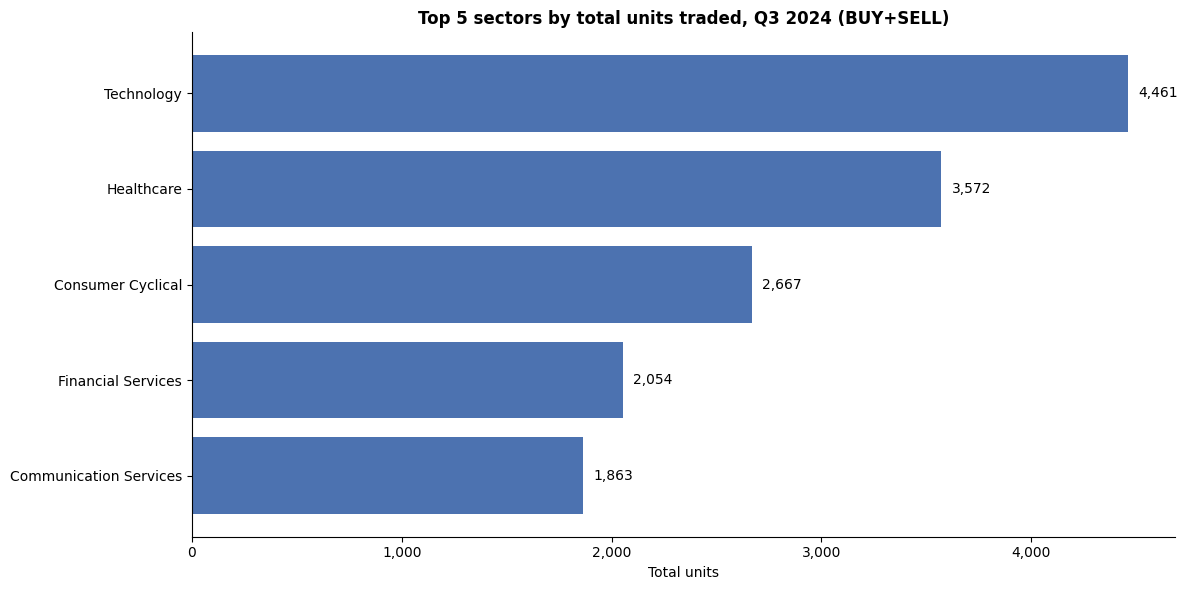

In [17]:
# Q6 - top 5 sectors by total units traded (BUY+SELL) in Q3 2024.
q6_mask = (star["transaction_type"].isin(["BUY", "SELL"]) &
           (star["quarter"] == 3) & (star["year"] == 2024))

q6 = (star[q6_mask]
      .groupby("sector")["units"].sum()
      .sort_values(ascending=False)
      .head(5))
print(q6)

sectors = q6.sort_values()
fig, ax = plt.subplots()
ax.barh(sectors.index, sectors.values, color="#4C72B0")
ax.set_title("Top 5 sectors by total units traded, Q3 2024 (BUY+SELL)")
ax.set_xlabel("Total units")
ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for i, v in enumerate(sectors.values):
    ax.text(v + 50, i, f"{int(v):,}", va="center")
plt.tight_layout()
plt.show()

### Interpretation

Measured in units, Q3 2024 is less top-heavy than the transaction counts. Technology still leads with 4,461 units, but Healthcare (3,572) and Consumer Cyclical (2,667) are not far behind, followed by Financial Services (2,054) and Communication Services (1,863). These five sectors together account for about 86% of the 16,962 units traded in the quarter.

# Business Question 7

## Top 10 symbols by BUY+SELL transactions (2024)

> What are the top 10 symbols by number of transactions (BUY + SELL) in 2024?

symbol  company_name                   
ARM     Arm Holdings plc                   100
AMD     Advanced Micro Devices, Inc.        97
TSM     Taiwan Semiconductor Manufactur     77
TIMB    TIM S.A.                            76
GOOG    Alphabet Inc.                       48
AMZN    Amazon.com, Inc.                    47
MSFT    Microsoft Corporation               45
ARDX    Ardelyx, Inc.                       43
BRFS    BRF S.A.                            42
RDDT    Reddit, Inc.                        40
Name: transaction_count, dtype: int64


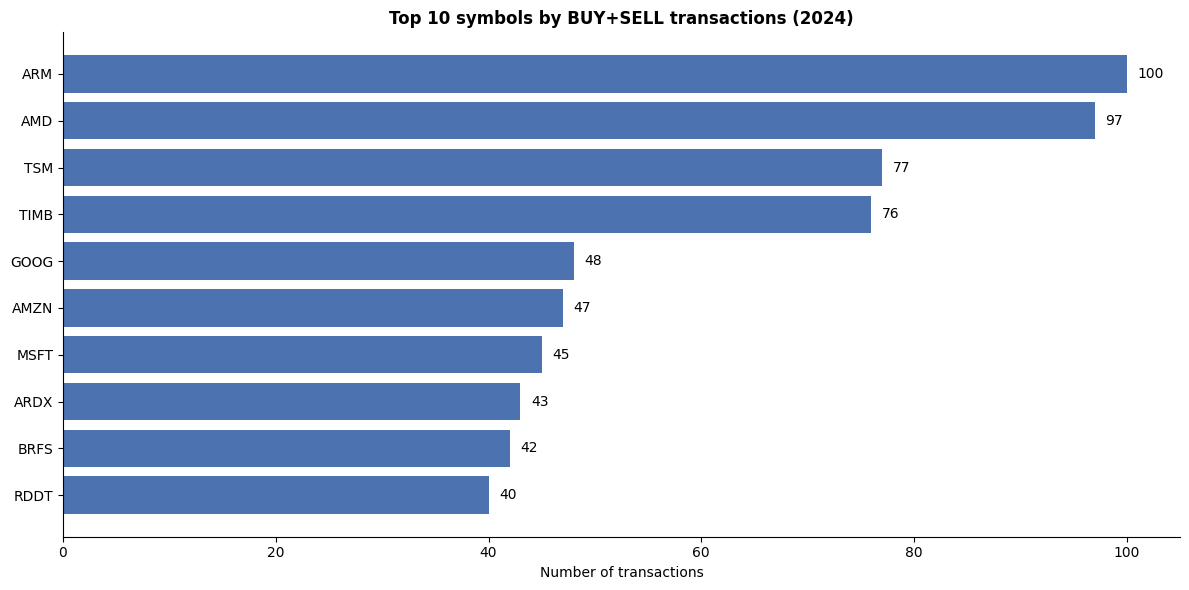

In [18]:
# Q7 - top 10 symbols by number of BUY+SELL transactions in 2024.
q7_mask = star["transaction_type"].isin(["BUY", "SELL"]) & (star["year"] == 2024)

q7 = (star[q7_mask]
      .groupby(["symbol", "company_name"])["transaction_count"].sum()
      .sort_values(ascending=False)
      .head(10))
print(q7)

# Chart by ticker (company names are in the table above).
plot_data = q7.sort_values()
labels = [sym for sym, _ in plot_data.index]
fig, ax = plt.subplots()
ax.barh(labels, plot_data.values, color="#4C72B0")
ax.set_title("Top 10 symbols by BUY+SELL transactions (2024)")
ax.set_xlabel("Number of transactions")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for i, v in enumerate(plot_data.values):
    ax.text(v + 1, i, str(int(v)), va="center")
plt.tight_layout()
plt.show()

### Interpretation

The most actively traded names are semiconductor and big-tech stocks: ARM (100) and AMD (97) lead, followed by TSMC (77) and the Brazilian telecom TIM (76). A second group around 40-48 transactions includes Alphabet, Amazon, Microsoft, Ardelyx, BRF and Reddit. Activity is spread across more names than in the sector view, but technology is again the clear theme at the top.

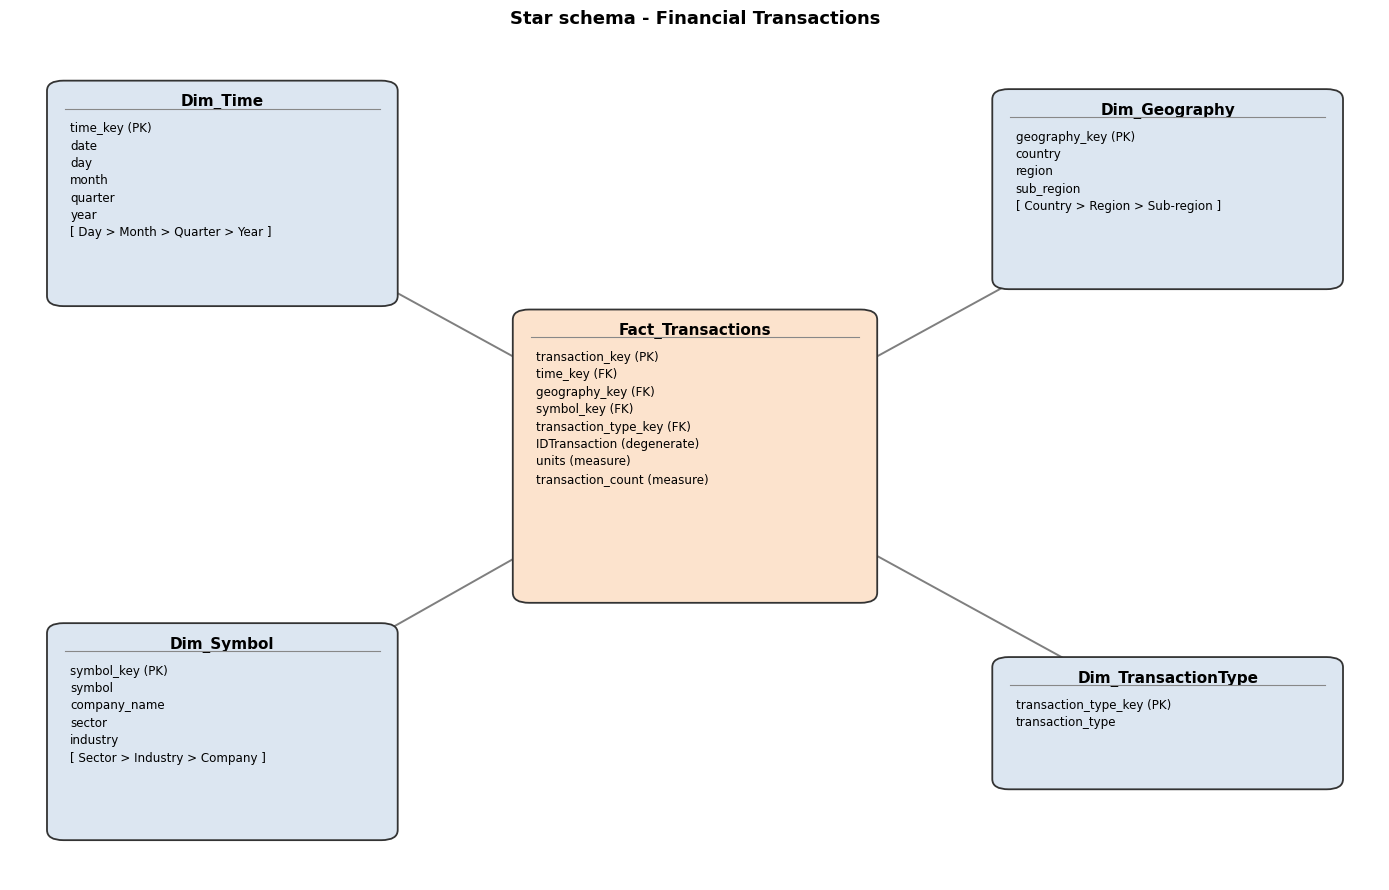

In [19]:
# ============================================================
# 12. Star schema diagram
# ============================================================

from matplotlib.patches import FancyBboxPatch

def draw_table(ax, x, y, w, h, title, rows, body):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.3,rounding_size=1.2",
                                linewidth=1.3, edgecolor="#333333", facecolor=body, zorder=3))
    ax.text(x + w / 2, y + h - 1.3, title, ha="center", va="top",
            fontsize=11, fontweight="bold", zorder=4)
    ax.plot([x + 1, x + w - 1], [y + h - 3.0, y + h - 3.0], color="#888888", lw=0.8, zorder=4)
    for i, r in enumerate(rows):
        ax.text(x + 1.4, y + h - 4.6 - i * 2.05, r, ha="left", va="top", fontsize=8.6, zorder=4)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

# Connector lines drawn first (center to center); the filled boxes hide the inner parts.
fact_c = (50, 50)
for c in [(15, 81), (85, 81), (15, 18), (85, 19)]:
    ax.plot([c[0], fact_c[0]], [c[1], fact_c[1]], color="#7f7f7f", lw=1.4, zorder=1)

draw_table(ax, 37, 33, 26, 34, "Fact_Transactions", [
    "transaction_key (PK)", "time_key (FK)", "geography_key (FK)",
    "symbol_key (FK)", "transaction_type_key (FK)", "IDTransaction (degenerate)",
    "units (measure)", "transaction_count (measure)"], "#FCE3CD")

draw_table(ax, 3, 68, 25, 26, "Dim_Time", [
    "time_key (PK)", "date", "day", "month", "quarter", "year",
    "[ Day > Month > Quarter > Year ]"], "#DCE6F1")

draw_table(ax, 72, 70, 25, 23, "Dim_Geography", [
    "geography_key (PK)", "country", "region", "sub_region",
    "[ Country > Region > Sub-region ]"], "#DCE6F1")

draw_table(ax, 3, 5, 25, 25, "Dim_Symbol", [
    "symbol_key (PK)", "symbol", "company_name", "sector", "industry",
    "[ Sector > Industry > Company ]"], "#DCE6F1")

draw_table(ax, 72, 11, 25, 15, "Dim_TransactionType", [
    "transaction_type_key (PK)", "transaction_type"], "#DCE6F1")

ax.set_title("Star schema - Financial Transactions", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("star_schema.png", dpi=130, bbox_inches="tight")
plt.show()

In [20]:
# ============================================================
# 13. Export the star schema tables to CSV
# ============================================================

# These CSVs feed the Streamlit app. We export each dimension and the fact.
OUTPUT_DIR = Path("star_data")
OUTPUT_DIR.mkdir(exist_ok=True)

tables = {
    "dim_time": dim_time,
    "dim_geography": dim_geography,
    "dim_symbol": dim_symbol,
    "dim_transaction_type": dim_transaction_type,
    "fact_transactions": fact_transactions,
}
for name, df in tables.items():
    df.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
    print(f"{name}.csv: {df.shape}")

dim_time.csv: (228, 6)
dim_geography.csv: (21, 4)
dim_symbol.csv: (111, 5)
dim_transaction_type.csv: (3, 2)
fact_transactions.csv: (2069, 8)
